# Libraries

In [9]:
import geopandas as gpd
import parcels as par
from parcels import FieldSet, ParticleSet, JITParticle, AdvectionRK4_3D,ParticleFile,ErrorCode,AdvectionRK4, Variable,VectorField,Field, FieldSamplingError
from parcels import plotTrajectoriesFile
import pandas as pd
from scipy import interpolate
from glob import glob
import numpy as np
from datetime import date,timedelta
import datetime
import xarray as xr
import pytz
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import imageio
import matplotlib.font_manager as fm
import math
pd.set_option("display.precision", 8)
from netCDF4 import Dataset
import numpy as np
#from mpl_toolkits.basemap import Basemap ## just needed to install basemap
from matplotlib.patches import Polygon
import warnings
from datetime import timedelta as delta
import pdb
#warnings.filterwarnings('ignore')

# Function just for plotting

In [10]:
def subset_hydromodel(latitudes, longitudes, lat_prtcl, lon_prtcl, variable):
    ## Subset of the hydromodel
    latmin = lat_prtcl - 0.07
    latmax = lat_prtcl + 0.07
    lonmin = lon_prtcl - 0.05
    lonmax = lon_prtcl + 0.05
    # getting index for lat and lon
    diff_max = np.abs(latmax - latitudes) + np.abs(lonmax - longitudes)
    diff_min = np.abs(latmin - latitudes) + np.abs(lonmin - longitudes)
    latlon_max = np.where(diff_max == diff_max.min())
    latlon_min = np.where(diff_min == diff_min.min())
    latmin = latlon_min[0].item(); lonmin = latlon_min[1].item()
    latmax = latlon_max[0].item(); lonmax = latlon_max[1].item()
    ## lat and lons for the selected area )
    subset_lons  = np.asarray(longitudes[latmin : latmax, lonmin : lonmax])
    subset_lats  = np.asarray(latitudes[latmin : latmax, lonmin : lonmax])
    subset_var   = np.asarray(variable[latmin : latmax, lonmin : lonmax])
    return(subset_lats, subset_lons, subset_var)

def get_simulation_boundaries(latitudes, longitudes, lat_bound, lon_bound):
    """ This function will help to create indx and recude the size domain """
    ## Subset of the hydromodel
    latmin = lat_bound[0] - 3.5
    latmax = lat_bound[1] + 3.5
    lonmin = lon_bound[0] - 1
    lonmax = lon_bound[1] + 1
    # getting index for lat and lon
    diff_max = np.abs(latmax - latitudes) + np.abs(lonmax - longitudes)
    diff_min = np.abs(latmin - latitudes) + np.abs(lonmin - longitudes)
    latlon_max = np.where(diff_max == diff_max.min())
    latlon_min = np.where(diff_min == diff_min.min())
    latmin = latlon_min[0].item(); lonmin = latlon_min[1].item()
    latmax = latlon_max[0].item(); lonmax = latlon_max[1].item()
    lat_index = [latmin, latmax]
    lon_index = [lonmin, lonmax]
    return(lat_index, lon_index)

def find_particle_index(latitudes, longitudes, part_lat, part_lon):
    """"This function looks for the indexes of each particle in the Xi-Yi 
    In which grid cell each particle is located.
    Use this function after setting the particles and before executing the run"""
    diff_grid = np.abs(part_lat - latitudes) + np.abs(part_lon - longitudes)
    XiYi = np.where(diff_grid == diff_grid.min())
    indexes = [XiYi[0].item(), XiYi[1].item()]
    return(indexes)


def DeleteParticle(particle, fieldset, time):
    particle.delete()
    
    
def polygon_boundary (shapefile_name, release_site_id):
    data_shape = gpd.read_file(shapefile_name)
    value_index = list(data_shape.loc[data_shape['FID'] == release_site_id].index)
    value_index = int("".join(map(str, value_index)))
    polygon = data_shape['geometry'][value_index]
    base_polygon = gpd.GeoSeries([polygon])
    bounds = polygon.bounds
    lon = [bounds[0], bounds[2]]
    lat = [bounds[1], bounds[3]]
    return (lat,lon)
    

In [11]:


data_path = '/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/Data/'
mesh_mask = data_path + 'coordinates.nc'
grid = xr.open_dataset(mesh_mask)
latitudes = grid['latitude']
longitudes = grid['longitude']
shapefile_name='/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/Shape_files/gbr1_coral_1m_merged.shp'
# polygons from [0-3805]
polygon_selected= 986 #1072 #986
bound_lat, bound_lon = polygon_boundary(shapefile_name, polygon_selected)

lat_idx, lon_idx = get_simulation_boundaries(latitudes, longitudes, bound_lat, bound_lon)

print(lat_idx)

[1398, 2152]


In [12]:
data_path = '/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/Data/'
mesh_mask = data_path + 'coordinates.nc'
grid = xr.open_dataset(mesh_mask)
latitudes = grid['latitude']
longitudes = grid['longitude']
print(latitudes)

lon_part = [145.53506554786637, 145.51936068493657, 145.5356358863923, 145.53145637880326, 145.52736346809914]
lat_part = [-14.859701485520151, -14.85834488238424, -14.86892276514238, -14.849033419881252, -14.862993266736664]


#lat_idx, lon_idx = get_boundaries(latitudes, longitudes,np.mean(lat_part), np.mean(lon_part))

print(range(lon_idx[0], lon_idx[1]))
print(range(lat_idx[0], lat_idx[1]))

<xarray.DataArray 'latitude' (j: 2389, i: 510)>
[1218390 values with dtype=float64]
Dimensions without coordinates: j, i
Attributes:
    units:            degrees_north
    long_name:        Latitude
    standard_name:    latitude
    coordinate_type:  latitude
    projection:       geographic
range(0, 311)
range(1398, 2152)


In [13]:
find_particle_index(latitudes, longitudes, lat_part[4],lon_part[4])

[1687, 216]

# OCEANPARCELS run for GBR1
### MRE

In [14]:
data_path = '/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/Data/'
files = sorted(glob(data_path+'gbr1_simple_*.nc'))
mesh_mask = data_path + 'coordinates.nc'
filenames = {'U': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': files[0], 'data': files},
             'V': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': files[0], 'data': files}}
variables = {'U': 'u',
             'V': 'v'}
dimensions = {'U': {'lon': 'longitude', 'lat': 'latitude', 'depth': 'zc', 'time': 'time'},
              'V': {'lon': 'longitude', 'lat': 'latitude', 'depth': 'zc', 'time': 'time'}}


indices = {'lon': range(0, 510), 'lat': range(lat_idx[0], lat_idx[1])}  # to load only a small part of the domain

#fieldset = FieldSet.from_netcdf(filenames, variables, dimensions, allow_time_extrapolation = True,indices=indices)
fieldset = FieldSet.from_netcdf(filenames, variables, dimensions, allow_time_extrapolation = True, chunksize='auto')





In [15]:

lon_part = [145.53506554786637, 145.51936068493657, 145.5356358863923, 145.53145637880326, 145.52736346809914]
lat_part = [-14.859701485520151, -14.85834488238424, -14.86892276514238, -14.849033419881252, -14.862993266736664]
## Depth tried -5.35; -2; -1
depth_part = [0]*len(lat_part)

pset = ParticleSet.from_list(fieldset, pclass=JITParticle,
                                 lon = lon_part,
                                 lat = lat_part,
                                 depth = depth_part)    
# setting the Kernel
kernels = pset.Kernel(AdvectionRK4) 
output_file = "/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/MRE"
pfile = pset.ParticleFile(output_file, outputdt = delta(hours=1))

# I tried for time = 0, 2, 3600, 7200 getting the same result
#fieldset.UV[7200, 0, lat_part[0], lon_part[0]]
print(pset)

P[5](lon=145.535065, lat=-14.859701, depth=0.000000, time=not_yet_set)
P[6](lon=145.519363, lat=-14.858345, depth=0.000000, time=not_yet_set)
P[7](lon=145.535629, lat=-14.868923, depth=0.000000, time=not_yet_set)
P[8](lon=145.531464, lat=-14.849033, depth=0.000000, time=not_yet_set)
P[9](lon=145.527359, lat=-14.862993, depth=0.000000, time=not_yet_set)


In [16]:
for p in pset:
    yi, xi = find_particle_index(latitudes, longitudes, p.lat, p.lon)
    p.xi = np.array([xi], dtype=np.int32)
    p.yi = np.array([yi], dtype=np.int32)

# Check if the particles are been seeded on water

INFO: Compiled ArrayJITParticleAdvectionRK4 ==> /tmp/parcels-546549/lib40e5ca99c4c2ece8451f18212ce27e33_0.so
INFO: Temporary output files are stored in /home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/out-HQJLOMEV.
INFO: You can use "parcels_convert_npydir_to_netcdf /home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/out-HQJLOMEV" to convert these to a NetCDF file during the run.
100%|████████████████████████████████| 86400.0/86400.0 [01:52<00:00, 771.08it/s]


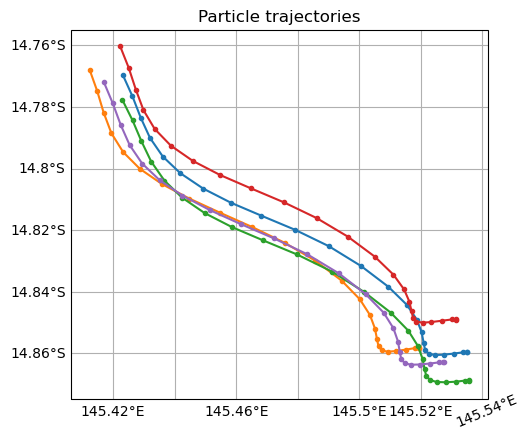

In [17]:
pset.execute(kernels, runtime = delta(days = 1), dt = delta(hours = 1),
             output_file = pfile, recovery = {ErrorCode.ErrorOutOfBounds: DeleteParticle})

pfile.export()  # export the trajectory data to a netcdf file
plotTrajectoriesFile(output_file+".nc");


In [ ]:
Hydro_file = '/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/Data/gbr1_simple_2014-12-02.nc'
## Hydro_file = '/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/Data/gbr1_simple_2014-12-02.nc'
hydro_nc = xr.open_dataset(Hydro_file)
latitudes = hydro_nc['latitude']
longitudes = hydro_nc['longitude']
u = hydro_nc['u'][3, 42]
v = hydro_nc['v'][3, 42]
z = hydro_nc['botz']
zc=hydro_nc['zc']

# plotting Polygons + Hydro + particles

In [ ]:
# Shapefile
shapefile_name='/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/Shape_files/gbr1_coral_1m_merged.shp'
# polygons from [0-3805]
polygon_selected=1072 #986
## reading the shape file
data_shape = gpd.read_file(shapefile_name)
value_index = list(data_shape.loc[data_shape['FID'] == polygon_selected].index)
value_index = int("".join(map(str, value_index)))
polygon = data_shape['geometry'][value_index]
base_polygon = gpd.GeoSeries([polygon])
bounds = polygon.bounds
def coord_lister(geom):
    coords = np.array(geom.exterior.coords)
    return (coords)
polygon_selected = base_polygon.geometry.apply(coord_lister).values[0]

# Get some parameters for the Stereographic Projection
lon_0 = np.nanmean((bounds[0],bounds[2]))
lat_0 = np.nanmean((bounds[1],bounds[3]))
## Subset the map
[subset_lats_U, subset_lons_U, subset_var_U] = subset_hydromodel(latitudes, longitudes, lat_0, lon_0, u)
[subset_lats_V, subset_lons_V, subset_var_V] = subset_hydromodel(latitudes, longitudes, lat_0, lon_0, v)
[subset_lats_Z, subset_lons_Z, subset_var_Z] = subset_hydromodel(latitudes, longitudes, lat_0, lon_0, z)


In [ ]:
fig=plt.figure(figsize=(10,12),facecolor='grey')
m = Basemap(llcrnrlon = subset_lons_V.min() ,llcrnrlat= subset_lats_V.min() ,urcrnrlon = subset_lons_V.max(), urcrnrlat = subset_lats_V.max(), \
            resolution='h',projection='lcc',lon_0 = lon_0, lat_0 = lat_0)
m.drawparallels(np.arange(-17., -13., .01), labels=[1,0,0,0], fontsize=10)
m.drawmeridians(np.arange(145., 147, .05), labels=[0,0,0,1], fontsize=10)
# Add Coastlines, States, and Country Boundaries
m.drawcoastlines()
#m.shadedrelief()
m.drawcountries()
m.fillcontinents(color='#cc9955', zorder = 0)
xp, yp=np.meshgrid(lon_part, lat_part)
xp, yp=m(xp,yp)
# Grid the co-ordinates
#X,Y = np.meshgrid(prt_lon_Nemo, prt_lat_Nemo)
lons,lats = m(subset_lons_U,subset_lats_U) # convert the co-ordinates to fit on the map
cs = m.pcolor(lons, lats, subset_var_Z, cmap='PuBu',vmin=0, vmax=40)
q1 = m.quiver(lons, lats, subset_var_U, subset_var_V, color='coral', scale=3,width=0.003)

xi_poly, yi_poly = m(polygon_selected[:,0], polygon_selected[:,1])
poly = Polygon(list(zip(xi_poly, yi_poly)) ,facecolor='none',edgecolor='red',linewidth=2)
plt.gca().add_patch(poly)
cbar = m.colorbar(cs, location='bottom', pad="10%")
cbar.set_label('Depth of sea-bed (m)')
m.plot(xp[0,:],yp[:,0],marker='o',color='red',linestyle = 'None')
m.plot(xp[0,:],yp[:,0],marker='+',color='black',linestyle = 'None')

plt.title('Seeding location', fontsize=14, fontweight = 'bold')
plt.quiverkey(q1, 0.12, 0.9, 0.1, 'GBR1 Hydro velocity', coordinates='axes')
plt.savefig('Figures/Seeding_location.png',edgecolor='grey')
plt.show()

In [ ]:
145.52250688691095, -14.857701180429903